# Camera capture experiment

Standalone notebook for testing and tuning camera-based tag capture: take a photo with this machine's webcam, see exactly how the quality gate scores it, and run it through the real pipeline -- all with fast iteration, without needing to launch the full Streamlit app each time.

**Kernel:** select "Python (igi-ocr)".

**Important caveat:** this notebook captures via OpenCV's `cv2.VideoCapture`, talking directly to whatever camera is attached to *this machine*. The deployed app instead uses `st.camera_input()`, which captures through the *browser's* camera API (`getUserMedia`) -- on a phone, through Windows 11 Phone Link, or through a different webcam driver, characteristics (default resolution, auto-exposure/focus behavior, compression) can all differ from what you see here. Treat this as a tool for understanding capture quality and tuning `quality.py`'s thresholds and `parsing.py`'s tolerance -- not as a pixel-perfect simulation of the deployed capture path.

**One concrete finding from building this notebook, already fixed in `app.py`:** `st.camera_input()`'s default resolution is tied to the *widget's on-screen display size* -- so shrinking the widget visually (done earlier, to make the live preview smaller) was also silently capturing lower-resolution photos. Fixed by passing `resolution="1080p"` explicitly, which requests a fixed target resolution independent of how large the widget is drawn.

## Setup

In [12]:
import sys
import time

sys.path.insert(0, "..")  # project root, so ocr/imaging/parsing/quality/pipeline import correctly
# (Jupyter's default working directory is this notebook's own folder)

import cv2
import matplotlib.pyplot as plt

import ocr
import pipeline
import quality

CAMERA_INDEX = 0  # <-- SET THIS. 0 is usually the built-in camera; a
                  # connected USB webcam is usually 1. Run the camera-
                  # discovery cell below to see which index is which,
                  # then change this number and re-run the cells after it.


def capture_frame(width=None, height=None, warmup_frames=5, warmup_delay=0.1):
    """Open the camera, optionally request a resolution, grab a frame, and
    guarantee the camera is released afterward -- even if this raises or the
    cell gets interrupted midway. Without try/finally here, an error partway
    through capture leaves the OS-level camera handle open for the rest of
    the kernel's life: the camera light stays on, and the next attempt to
    open the same camera index fails outright (no two DSHOW handles can
    normally open the same device at once)."""
    cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
    try:
        if width is not None:
            cap.set(cv2.CAP_PROP_FRAME_WIDTH, width)
        if height is not None:
            cap.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
        ret = False
        for _ in range(warmup_frames):
            ret, frame = cap.read()
            time.sleep(warmup_delay)
        if not ret:
            raise RuntimeError(
                "Failed to read from the camera. Check CAMERA_INDEX, that no "
                "other program has it open, and that the safety-net cell "
                "below doesn't report a stray handle."
            )
        return frame
    finally:
        cap.release()

## If the camera light won't turn off

Run the cell below. It releases a previous `cap` handle still sitting in this notebook's memory (e.g. left over from before this notebook's cells used `try`/`finally`). If it reports no stray handle and the light is still on, the fix is to restart the kernel -- that force-closes every OS-level handle the process holds, including the camera.

In [13]:
if "cap" in globals() and cap is not None:
    cap.release()
    print("Released a stray camera handle found in this notebook's memory.")
else:
    print("No stray handle found in this session. If the light is still on, restart the kernel.")

Released a stray camera handle found in this notebook's memory.


## Which camera is which? (run this first)

Captures one thumbnail from every camera index the machine exposes and shows them side by side with their index number and resolution. Find the one that's your connected webcam, note its index, then set `CAMERA_INDEX` in the Setup cell to that number and re-run from there.

If the connected webcam doesn't appear at all, it's being held by another program (a browser tab with the app's camera widget open, Windows Camera, Teams/Zoom, etc.) — close that first.

In [ ]:
def probe_camera(idx, warmup=5, delay=0.1):
    """Grab one frame + its resolution from camera `idx`, always releasing."""
    cap = cv2.VideoCapture(idx, cv2.CAP_DSHOW)
    try:
        if not cap.isOpened():
            return None
        # request 1080p so the reported resolution reflects the camera's
        # real capability, not VideoCapture's low default
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
        ret = False
        for _ in range(warmup):
            ret, frame = cap.read()
            time.sleep(delay)
        return frame if ret else None
    finally:
        cap.release()


found = []
for idx in range(4):  # check indices 0-3
    frame = probe_camera(idx)
    if frame is not None:
        found.append((idx, frame))
        print(f"index {idx}: available, {frame.shape[1]}x{frame.shape[0]}")
    else:
        print(f"index {idx}: not available")

if found:
    fig, axes = plt.subplots(1, len(found), figsize=(6 * len(found), 5))
    if len(found) == 1:
        axes = [axes]
    for ax, (idx, frame) in zip(axes, found):
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"index {idx}  ({frame.shape[1]}x{frame.shape[0]})")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No cameras available. Close any program holding the camera and re-run.")

## What resolutions does this camera actually support?

`cv2.VideoCapture`'s default resolution is often much lower than the camera's real capability (commonly 640x480) unless you explicitly request higher. This cell requests a few common resolutions and reports what the driver actually returns -- run it once to know your camera's real ceiling before capturing.

In [14]:
cap = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_DSHOW)
try:
    print("default:", cap.get(cv2.CAP_PROP_FRAME_WIDTH), "x", cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    for w, h in [(1280, 720), (1920, 1080), (3840, 2160)]:
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, w)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, h)
        actual_w, actual_h = cap.get(cv2.CAP_PROP_FRAME_WIDTH), cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
        print(f"requested {w}x{h} -> got {actual_w:.0f}x{actual_h:.0f}")
finally:
    cap.release()

default: 640.0 x 480.0
requested 1280x720 -> got 1280x720
requested 1920x1080 -> got 1280x720
requested 3840x2160 -> got 1280x720


## Capture a photo

Position a real IGI tag in front of the camera, then run this cell. Re-run it any time to grab a fresh frame (e.g. after adjusting lighting/angle/distance). `CAPTURE_WIDTH`/`CAPTURE_HEIGHT` request the camera's best resolution found above.

captured: (720, 1280, 3)


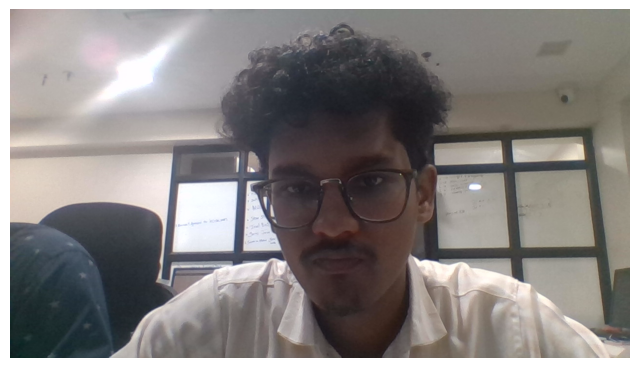

In [15]:
CAPTURE_WIDTH, CAPTURE_HEIGHT = 1280, 720  # set to whatever this camera actually supports, from the cell above

frame = capture_frame(width=CAPTURE_WIDTH, height=CAPTURE_HEIGHT)
print("captured:", frame.shape)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Quality gate diagnostics

Runs the same checks `quality.assess_quality` uses in the real pipeline, but prints the actual numbers (blur variance, dark/bright pixel ratios, OCR character count) instead of just pass/fail -- useful for seeing *how close* a marginal shot is, not just whether it was accepted.

In [7]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

is_sharp, variance = quality.check_blur(gray)
print(f"blur variance: {variance:.1f} (threshold {quality.BLUR_VARIANCE_THRESHOLD}) -> {'OK' if is_sharp else 'TOO BLURRY'}")

exposure_ok, reason = quality.check_exposure(gray)
print(f"exposure: {'OK' if exposure_ok else reason}")

text_ok, char_count = quality.check_text_presence(gray, ocr.run_ocr)
print(f"OCR text-presence: {char_count} chars found (need {quality.MIN_OCR_CHARS}) -> {'OK' if text_ok else 'NOT ENOUGH TEXT'}")

accepted, reason = quality.assess_quality(frame, ocr.run_ocr)
print()
print("Overall:", "ACCEPTED" if accepted else f"REJECTED -- {reason}")

blur variance: 42.7 (threshold 5.0) -> OK
exposure: OK


c:\Users\HP\miniconda3\envs\igi-ocr\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_tiny_det', 'd:\\IGI_OCR\\notebooks\\..\\models\\PP-OCRv6_tiny_det', None)
Creating model: ('PP-OCRv6_tiny_rec', 'd:\\IGI_OCR\\notebooks\\..\\models\\PP-OCRv6_tiny_rec', None)


OCR text-presence: 107 chars found (need 10) -> OK

Overall: ACCEPTED


## Run it through the real pipeline

Same `pipeline.process_image` the deployed app calls -- barcode/QR decode, OCR, field parsing, validation. Encodes the captured frame as JPEG bytes first, matching what the app receives from `st.camera_input()`/`st.file_uploader`.

In [8]:
ok, buffer = cv2.imencode(".jpg", frame)
assert ok
image_bytes = buffer.tobytes()

result = pipeline.process_image(image_bytes, "camera_capture.jpg")
result

{'filename': 'camera_capture.jpg',
 'accepted': True,
 'raw_ocr_text': 'International Gemological intue\nC141624 REPORT\nTIIRERUIUIOD CVD\nIGI CERT -800634952\n5.07\nCERT Liak FIY VVS2\nCUSHION\nCa FX PalFX Sum FX',
 'igi_report_no': '800634952',
 'report_type': 'CVD',
 'shape': 'CUSHION',
 'carat': '5.07',
 'color': 'Y',
 'clarity': 'VVS2',
 'needs_review': False}

## Burst comparison

Capture several frames in a row (e.g. while trying different distances, angles, or lighting) and compare their quality metrics side by side. Re-run the capture cell between each entry, or adapt this into a loop with `time.sleep` between shots if you want to physically move the camera/tag between captures.

In [9]:
# Each time you like a capture from above, append it here for comparison:
# burst.append(("label describing this shot", frame.copy()))
burst = []

In [10]:
burst.append(("e.g. 30cm, ceiling light", frame.copy()))
print(f"{len(burst)} shot(s) in burst")

1 shot(s) in burst


In [11]:
for label, shot in burst:
    gray_shot = cv2.cvtColor(shot, cv2.COLOR_BGR2GRAY)
    _, variance = quality.check_blur(gray_shot)
    _, exposure_reason = quality.check_exposure(gray_shot)
    accepted, reason = quality.assess_quality(shot, ocr.run_ocr)
    ok, buf = cv2.imencode(".jpg", shot)
    parsed = pipeline.process_image(buf.tobytes(), label)
    print(f"=== {label} ===")
    print(f"  shape={shot.shape}  blur_variance={variance:.1f}  exposure={exposure_reason or 'ok'}")
    print(f"  quality gate: {'ACCEPTED' if accepted else f'REJECTED ({reason})'}")
    if parsed["accepted"]:
        print(f"  needs_review={parsed['needs_review']}  fields={ {k: parsed[k] for k in ['igi_report_no','report_type','shape','carat','color','clarity']} }")
    print()

=== e.g. 30cm, ceiling light ===
  shape=(720, 1280, 3)  blur_variance=42.7  exposure=ok
  quality gate: ACCEPTED
  needs_review=False  fields={'igi_report_no': '800634952', 'report_type': 'CVD', 'shape': 'CUSHION', 'carat': '5.07', 'color': 'Y', 'clarity': 'VVS2'}

